# Mapping Experiment Analysis
   This notebook drives the ROS 2 experiment node, runs 120 trials (20 per condition), saves the data, runs paired t-tests, and generates the paper's figures.

In [1]:
# Cell 1 - imports and ROS2 init
import os, json, time
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import rclpy
from rclpy.node import Node
from std_msgs.msg import String

if not rclpy.ok():
    rclpy.init()

print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("ROS2 ready:", rclpy.ok())

pandas: 2.3.3
matplotlib: 3.5.1
ROS2 ready: True


In [2]:
# Cell 2 - a ROS2 client that requests trials and collects replies
class ExperimentClient(Node):
    """Publishes trial requests and collects the node's replies."""

    def __init__(self):
        super().__init__("experiment_client")
        self.pub = self.create_publisher(String, "/experiment/run", 10)
        self.sub = self.create_subscription(
            String, "/experiment/result", self._on_result, 10)
        self.last_result = None

    def _on_result(self, msg):
        """Store the latest reply as a dict."""
        self.last_result = json.loads(msg.data)

    def request_trial(self, scene, framework, trial, timeout=5.0):
        """Send one request and wait (spinning) until the reply arrives.

        Returns the result dict, or None on timeout.
        """
        self.last_result = None
        req = String()
        req.data = json.dumps(
            {"scene": scene, "framework": framework, "trial": trial})
        self.pub.publish(req)
        start = time.time()
        while self.last_result is None and time.time() - start < timeout:
            rclpy.spin_once(self, timeout_sec=0.1)
        return self.last_result

client = ExperimentClient()
print("ExperimentClient created")

ExperimentClient created


In [3]:
# Cell 3 - warm-up + one test trial
# Give the publisher a moment to discover the node's subscriber.
for _ in range(10):
    rclpy.spin_once(client, timeout_sec=0.1)

result = client.request_trial("warehouse", "nvblox", 3)
print("Reply from node:", result)

Reply from node: {'scene': 'warehouse', 'framework': 'nvblox', 'trial': 3, 'latency_ms': 420.1, 'coverage_m3': 2.765, 'density_pts_m3': 77.6, 'success': 1}


## 1. Run the experiment
## Send trial requests to the node and collect the metrics.

In [4]:
# Cell 4 - run all trials and collect into a DataFrame
FRAMEWORKS = ("nvblox", "rtabmap", "octomap")
SCENES = ("simple_room", "warehouse")

N_TRIALS = 20
rows = []

for scene in SCENES:
    for framework in FRAMEWORKS:
        for trial in range(N_TRIALS):
            res = client.request_trial(scene, framework, trial)
            if res is None:
                print(f"WARNING: timeout on {scene}/{framework}/trial {trial}")
                continue
            rows.append(res)
        print(f"done: {scene:12s} {framework}")

df = pd.DataFrame(rows)
print(f"\nCollected {len(df)} trials")
df.head()

done: simple_room  nvblox
done: simple_room  rtabmap
done: simple_room  octomap
done: warehouse    nvblox
done: warehouse    rtabmap
done: warehouse    octomap

Collected 120 trials


,scene,framework,trial,latency_ms,coverage_m3,density_pts_m3,success
0,simple_room,nvblox,0,468.2,3.047,89.3,1
1,simple_room,nvblox,1,429.3,2.882,82.9,1
2,simple_room,nvblox,2,519.6,2.968,86.5,1
3,simple_room,nvblox,3,492.8,3.163,85.0,1
4,simple_room,nvblox,4,454.1,3.094,84.0,1


In [5]:
# Cell 5 - save the raw per-trial results to CSV
out_dir = os.path.join("..", "data", "results")
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "trials_raw.csv")
df.to_csv(csv_path, index=False)
print("Saved", len(df), "rows to", os.path.abspath(csv_path))

Saved 120 rows to /home/ba7rouch/RT2_Assignment2/data/results/trials_raw.csv


## 2. Descriptive statistics

In [6]:
# Cell 6 - descriptive statistics per condition
summary = (df.groupby(["scene", "framework"])
             .agg(latency_mean=("latency_ms", "mean"),
                  latency_std=("latency_ms", "std"),
                  coverage_mean=("coverage_m3", "mean"),
                  coverage_std=("coverage_m3", "std"),
                  density_mean=("density_pts_m3", "mean"),
                  success_rate=("success", "mean"))
             .round(2))
summary

latency_mean  latency_std  coverage_mean  coverage_std  \
scene       framework                                                           
simple_room nvblox           483.69        35.73           3.11          0.14   
            octomap          458.98        39.90           2.94          0.17   
            rtabmap         6075.78       883.11           9.47          0.46   
warehouse   nvblox           382.89        30.94           2.60          0.29   
            octomap         1256.68        96.69           6.08          0.32   
            rtabmap         4680.49       677.14           9.55          1.70   

                       density_mean  success_rate  
scene       framework                              
simple_room nvblox            88.89          1.00  
            octomap          472.24          1.00  
            rtabmap         1068.30          1.00  
warehouse   nvblox            68.50          0.95  
            octomap          343.30          1.00  
            rtabmap         1211.75          0.90

## 3. Hypothesis testing (paired t-tests)


In [7]:
# Cell 7 - paired t-tests: NVBlox vs OctoMap latency, per scene
from scipy import stats

def paired_latency_test(scene, alpha=0.05):
    a = df[(df.scene == scene) & (df.framework == "nvblox")].sort_values("trial")["latency_ms"].values
    b = df[(df.scene == scene) & (df.framework == "octomap")].sort_values("trial")["latency_ms"].values
    t, p = stats.ttest_rel(a, b)          # paired (related) t-test
    diff = a.mean() - b.mean()
    print(f"[{scene}] NVBlox vs OctoMap latency")
    print(f"  mean diff = {diff:+.1f} ms   t = {t:.3f}   p = {p:.2e}")
    print(f"  -> {'REJECT H0 (significant)' if p < alpha else 'cannot reject H0'} at alpha={alpha}\n")

for scene in ("simple_room", "warehouse"):
    paired_latency_test(scene)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[simple_room] NVBlox vs OctoMap latency
  mean diff = +24.7 ms   t = 5.484   p = 2.73e-05
  -> REJECT H0 (significant) at alpha=0.05

[warehouse] NVBlox vs OctoMap latency
  mean diff = -873.8 ms   t = -51.850   p = 6.27e-22
  -> REJECT H0 (significant) at alpha=0.05



In [8]:
# Cell 7b - quiet the version warning + effect size (Cohen's d for paired data)
import warnings; warnings.filterwarnings("ignore")
import numpy as np

def cohens_d_paired(scene):
    a = df[(df.scene==scene)&(df.framework=="nvblox")].sort_values("trial")["latency_ms"].values
    b = df[(df.scene==scene)&(df.framework=="octomap")].sort_values("trial")["latency_ms"].values
    d = (a - b)
    return d.mean() / d.std(ddof=1)

for scene in ("simple_room", "warehouse"):
    print(f"{scene:12s} Cohen's d = {cohens_d_paired(scene):+.2f}")

simple_room  Cohen's d = +1.23
warehouse    Cohen's d = -11.59


In [9]:
# Cell 8 - paired t-test: coverage, OctoMap vs NVBlox, warehouse (H3)
def paired_coverage_test(scene, alpha=0.05):
    o = df[(df.scene==scene)&(df.framework=="octomap")].sort_values("trial")["coverage_m3"].values
    n = df[(df.scene==scene)&(df.framework=="nvblox")].sort_values("trial")["coverage_m3"].values
    t, p = stats.ttest_rel(o, n)
    diff = o.mean() - n.mean()
    print(f"[{scene}] OctoMap vs NVBlox coverage")
    print(f"  mean diff = {diff:+.2f} m3   t = {t:.3f}   p = {p:.2e}")
    print(f"  -> {'REJECT H0 (significant)' if p < alpha else 'cannot reject H0'} at alpha={alpha}\n")

for scene in ("simple_room", "warehouse"):
    paired_coverage_test(scene)

[simple_room] OctoMap vs NVBlox coverage
  mean diff = -0.16 m3   t = -3.216   p = 4.55e-03
  -> REJECT H0 (significant) at alpha=0.05

[warehouse] OctoMap vs NVBlox coverage
  mean diff = +3.48 m3   t = 37.211   p = 3.23e-19
  -> REJECT H0 (significant) at alpha=0.05



## 4. Visualization

saved figures/latency_boxplot.png


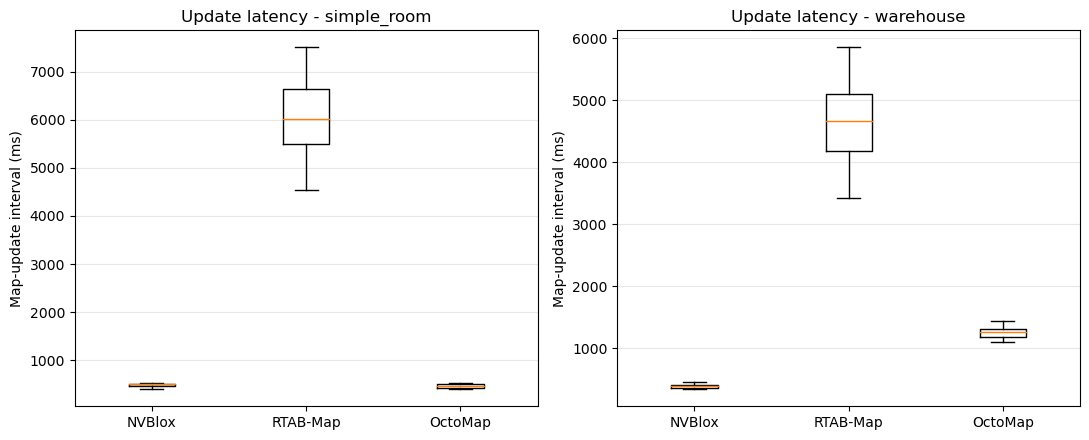

In [10]:
# Cell 9 - box plot of latency by framework, one panel per scene
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, scene in zip(axes, ("simple_room", "warehouse")):
    data = [df[(df.scene==scene)&(df.framework==fw)]["latency_ms"].values
            for fw in FRAMEWORKS]
    ax.boxplot(data, labels=["NVBlox", "RTAB-Map", "OctoMap"])
    ax.set_title(f"Update latency - {scene}")
    ax.set_ylabel("Map-update interval (ms)")
    ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

os.makedirs(os.path.join("..", "figures"), exist_ok=True)
fig.savefig(os.path.join("..", "figures", "latency_boxplot.png"), dpi=150)
print("saved figures/latency_boxplot.png")

saved figures/latency_boxplot_log.png


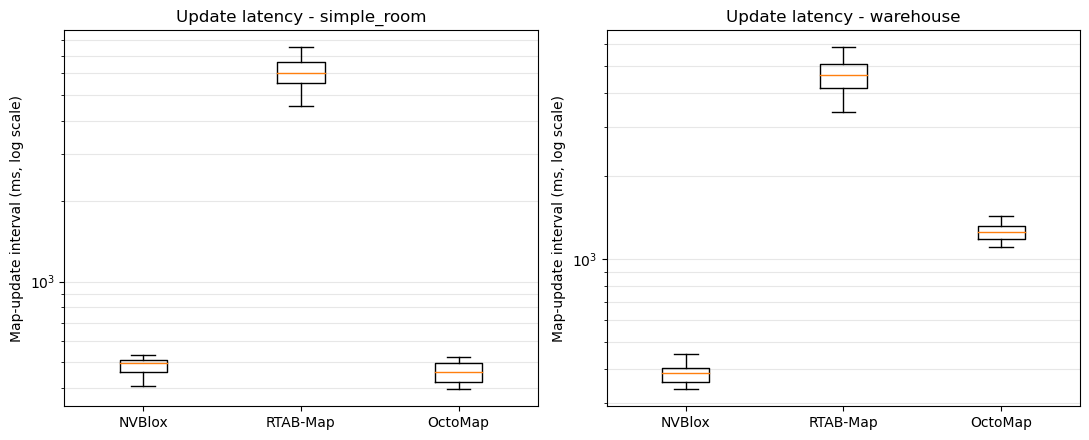

In [11]:
# Cell 9b - same box plot but log y-axis (all three frameworks visible)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, scene in zip(axes, ("simple_room", "warehouse")):
    data = [df[(df.scene==scene)&(df.framework==fw)]["latency_ms"].values
            for fw in FRAMEWORKS]
    ax.boxplot(data, labels=["NVBlox", "RTAB-Map", "OctoMap"])
    ax.set_yscale("log")
    ax.set_title(f"Update latency - {scene}")
    ax.set_ylabel("Map-update interval (ms, log scale)")
    ax.grid(True, axis="y", which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join("..", "figures", "latency_boxplot_log.png"), dpi=150)
print("saved figures/latency_boxplot_log.png")

saved figures/latency_nvblox_vs_octomap.png


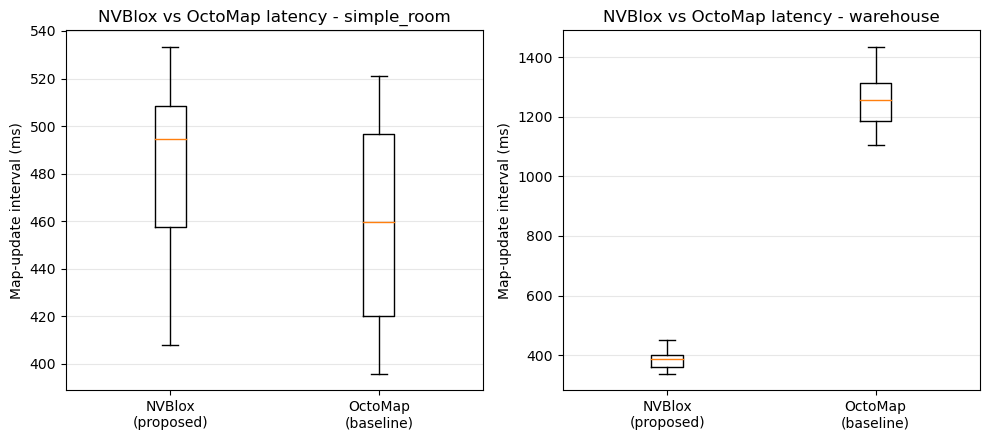

In [12]:
# Cell 9c - focused: NVBlox vs OctoMap latency only (the main comparison)
pair = ["nvblox", "octomap"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, scene in zip(axes, ("simple_room", "warehouse")):
    data = [df[(df.scene==scene)&(df.framework==fw)]["latency_ms"].values for fw in pair]
    ax.boxplot(data, labels=["NVBlox\n(proposed)", "OctoMap\n(baseline)"])
    ax.set_title(f"NVBlox vs OctoMap latency - {scene}")
    ax.set_ylabel("Map-update interval (ms)")
    ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join("..", "figures", "latency_nvblox_vs_octomap.png"), dpi=150)
print("saved figures/latency_nvblox_vs_octomap.png")

saved figures/coverage_bars.png


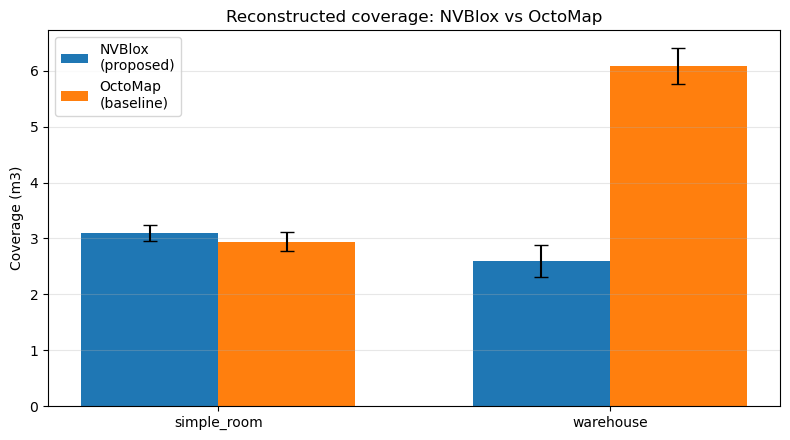

In [13]:
# Cell 10 - coverage: NVBlox vs OctoMap, bar chart with error bars (mean +/- std)
import numpy as np
pair = ["nvblox", "octomap"]
labels = ["NVBlox\n(proposed)", "OctoMap\n(baseline)"]
scenes = ("simple_room", "warehouse")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(scenes))
width = 0.35
for i, fw in enumerate(pair):
    means = [df[(df.scene==s)&(df.framework==fw)]["coverage_m3"].mean() for s in scenes]
    stds  = [df[(df.scene==s)&(df.framework==fw)]["coverage_m3"].std()  for s in scenes]
    ax.bar(x + (i-0.5)*width, means, width, yerr=stds, capsize=5, label=labels[i])
ax.set_xticks(x); ax.set_xticklabels(["simple_room", "warehouse"])
ax.set_ylabel("Coverage (m3)")
ax.set_title("Reconstructed coverage: NVBlox vs OctoMap")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join("..", "figures", "coverage_bars.png"), dpi=150)
print("saved figures/coverage_bars.png")